# Работа по теме "Исследование данных, их визуализация и интерпретация"

## Описание

Работа предполагает самостоятельное исследование данных. Предполагается использование различных функций и методов работы с данными (фильтрация, сортировка, группировка, сводные таблицы и т.д.). Везде, где это допустимо и приемлемо, использовать визуализацию с использованием различных библиотек. Тип графика подбирать исходя и данных для наилучшего их отображения. К каждому расчету и графику необходимо словесное пояснение, интерпертация результатов, выводы. Приветствуется постепенное углубление в данные. когда результаты одного расчета позволяют сделать предположение и проверять его дальнейшими расчетами.

Плюсом будет являться использование не рассмотренных ранее функций, библиотек и типов визуализации. Их использование демонстрирует умение самостоятельно изучить возможности библиотек и применить их.

Далее даны некоторые направления работы, которые стоит рассмотреть. Однако, это не полный список задач, необходимо в процессе знакомства с данными продлевать исследовательские цепочки, ставить самостоятельно новые задачи и решать их.

Примерные критерии оценки:
- Использование различных возможностей работы с данными (фильтрация, сортировка, группировка, сводные таблицы, дискретизация и т.д.)
- Сопровождение расчетов визуализацией.
- Адекватный данным выбор типа визуализации.
- Оформление графиков.
- Текстовое сопровождение: описание выполняемых операций, наблюдаемых зависимостей, выводов.
- Последовательности углубления в данные с постановкой гипотез.
- Наличие дополнительных тем для рассмотрения.

Результатом работы должен стать блокнот с исследованием данных, из которого должно быть ясно содержание данных, основные зависимости, интересные наблюдения.

# Покемоны

## Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Данные

Исходные данные - файл "pokemon.csv". Самостоятельно найдите и вставьте описание данных и столбцов (точно есть на Kaggle).

Не забудьте ознакомиться с данными и предобработать их при необходимости, либо описать, почему обрабатывать не надо.

*   name: The English name of the Pokemon
*   japanese_name: The Original Japanese name of the Pokemon
*   pokedex_number: The entry number of the Pokemon in the National Pokedex
*   percentage_male: The percentage of the species that are male. Blank if the *   Pokemon is genderless.
*   type1: The Primary Type of the Pokemon
*   type2: The Secondary Type of the Pokemon
*   classification: The Classification of the Pokemon as described by the Sun and Moon Pokedex
*   height_m: Height of the Pokemon in metres
*   weight_kg: The Weight of the Pokemon in kilograms
*   capture_rate: Capture Rate of the Pokemon
*   base_egg_steps: The number of steps required to hatch an egg of the Pokemon
*   abilities: A stringified list of abilities that the Pokemon is capable of having
*   experience_growth: The Experience Growth of the Pokemon
*   base_happiness: Base Happiness of the Pokemon
*   against_?: Eighteen features that denote the amount of damage taken against an attack of a particular type
*   hp: The Base HP of the Pokemon
*   attack: The Base Attack of the Pokemon
*   defense: The Base Defense of the Pokemon
*   sp_attack: The Base Special Attack of the Pokemon
*   sp_defense: The Base Special Defense of the Pokemon
*   speed: The Base Speed of the Pokemon
*   generation: The numbered generation which the Pokemon was first introduced
*   is_legendary: Denotes if the Pokemon is legendary.

In [1]:
columns = ['name', 'base_total', 'percentage_male', 'type1', 'type2',
           'height_m', 'weight_kg', 'capture_rate', 'base_egg_steps',
           'experience_growth', 'base_happiness', 'hp', 'attack',
           'defense', 'speed', 'generation', 'is_legendary']

In [5]:
df = pd.read_csv('pokemon.csv')
df.sample(10)

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
139,"['Swift Swim', 'Battle Armor', 'Weak Armor']",1.0,1.00,1.0,2.0,1.0,2.0,0.25,0.5,1.0,...,88.1,140,55,45,55,rock,water,11.5,1,0
558,"['Shed Skin', 'Moxie', 'Intimidate']",1.0,0.25,1.0,1.0,4.0,2.0,1.00,2.0,0.5,...,50.0,559,35,70,48,dark,fighting,11.8,5,0
460,"['Pressure', 'Pickpocket']",2.0,0.50,1.0,1.0,2.0,4.0,2.00,1.0,0.5,...,50.0,461,45,85,125,dark,ice,34.0,4,0
237,"['Oblivious', 'Forewarn', 'Hydration']",2.0,2.00,1.0,1.0,1.0,1.0,2.00,1.0,2.0,...,0.0,238,85,65,65,ice,psychic,6.0,2,0
241,"['Natural Cure', 'Serene Grace', 'Healer']",1.0,1.00,1.0,1.0,1.0,2.0,1.00,1.0,0.0,...,0.0,242,75,135,55,normal,NaN,46.8,2,0
282,"['Swift Swim', 'Rain Dish']",1.0,1.00,1.0,2.0,1.0,0.5,1.00,2.0,1.0,...,50.0,283,50,52,65,bug,water,1.7,3,0
284,"['Effect Spore', 'Poison Heal', 'Quick Feet']",2.0,1.00,1.0,0.5,1.0,1.0,2.00,2.0,1.0,...,50.0,285,40,60,35,grass,NaN,4.5,3,0
206,"['Hyper Cutter', 'Sand Veil', 'Immunity']",0.5,1.00,1.0,0.0,1.0,0.5,1.00,1.0,1.0,...,50.0,207,35,65,85,ground,flying,64.8,2,0
54,"['Damp', 'Cloud Nine', 'Swift Swim']",1.0,1.00,1.0,2.0,1.0,1.0,0.50,1.0,1.0,...,50.0,55,95,80,85,water,NaN,76.6,1,0
750,"['Water Bubble', 'Water Absorb']",1.0,1.00,1.0,2.0,1.0,0.5,1.00,2.0,1.0,...,50.0,751,40,72,27,water,bug,4.0,7,0


## Исследование

Далее описаны некоторые возможные направления изучения данных. Список не закрытый, его можно дополнять своими задачами, предположениями, гипотезами.

1. Самые-самые покемоны по разным основаниям. Что у них общего и чем они отличаются?
2. Сильнейшие покемоны каждого поколения.
3. Насколько легендарные покемоны сильнее? А по разным типам или поколениям?
4. Среди покемонов каких типов больше всего легендарных?
5. Средние характеристики (любые интересные) для покемонов по типам и поколениям.
6. Есть ли связь характеристик и роста покемонов? Веса?
7. Какие характеристики могут быть ключевыми для предсказания силы покемона?

In [6]:
import ast
df['abilities'].apply(ast.literal_eval).explode().unique()

array(['Overgrow', 'Chlorophyll', 'Blaze', 'Solar Power', 'Torrent',
       'Rain Dish', 'Shield Dust', 'Run Away', 'Shed Skin',
       'Compoundeyes', 'Tinted Lens', 'Swarm', 'Sniper', 'Keen Eye',
       'Tangled Feet', 'Big Pecks', 'Guts', 'Hustle', 'Gluttony',
       'Thick Fat', 'Intimidate', 'Unnerve', 'Static', 'Lightningrod',
       'Surge Surfer', 'Sand Veil', 'Sand Rush', 'Snow Cloak',
       'Slush Rush', 'Poison Point', 'Rivalry', 'Sheer Force',
       'Cute Charm', 'Magic Guard', 'Friend Guard', 'Unaware',
       'Flash Fire', 'Drought', 'Snow Warning', 'Competitive', 'Frisk',
       'Inner Focus', 'Infiltrator', 'Stench', 'Effect Spore', 'Dry Skin',
       'Damp', 'Wonder Skin ', 'Arena Trap', 'Sand Force',
       'Tangling Hair', 'Pickup', 'Technician', 'Rattled', 'Limber',
       'Fur Coat', 'Cloud Nine', 'Swift Swim', 'Vital Spirit',
       'Anger Point', 'Defiant', 'Justified', 'Water Absorb',
       'Synchronize', 'No Guard', 'Steadfast', 'Clear Body',
       'Liquid 

In [7]:
df['type1'].unique()

array(['grass', 'fire', 'water', 'bug', 'normal', 'poison', 'electric',
       'ground', 'fairy', 'fighting', 'psychic', 'rock', 'ghost', 'ice',
       'dragon', 'dark', 'steel', 'flying'], dtype=object)

In [8]:
df['type2'].unique()

array(['poison', nan, 'flying', 'dark', 'electric', 'ice', 'ground',
       'fairy', 'grass', 'fighting', 'psychic', 'steel', 'fire', 'rock',
       'water', 'dragon', 'ghost', 'bug', 'normal'], dtype=object)

In [9]:
len(df[df['type2'].isna()]) # 384 покемона без второго типа

384

In [10]:
df.describe()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,height_m,hp,percentage_male,pokedex_number,sp_attack,sp_defense,speed,weight_kg,generation,is_legendary
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,781.000000,801.000000,703.000000,801.000000,801.000000,801.000000,801.000000,781.000000,801.000000,801.000000
mean,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,1.034020,...,1.163892,68.958801,55.155761,401.000000,71.305868,70.911361,66.334582,61.378105,3.690387,0.087391
std,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,0.788896,...,1.080326,26.576015,20.261623,231.373075,32.353826,27.942501,28.907662,109.354766,1.930420,0.282583
min,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,...,0.100000,1.000000,0.000000,1.000000,10.000000,20.000000,5.000000,0.100000,1.000000,0.000000
25%,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,0.500000,...,0.600000,50.000000,50.000000,201.000000,45.000000,50.000000,45.000000,9.000000,2.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,65.000000,50.000000,401.000000,65.000000,66.000000,65.000000,27.300000,4.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.500000,80.000000,50.000000,601.000000,91.000000,90.000000,85.000000,64.800000,5.000000,0.000000
max,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,14.500000,255.000000,100.000000,801.000000,194.000000,230.000000,180.000000,999.900000,7.000000,1.000000


In [15]:
df = df[columns]

In [16]:
data = df['is_legendary'].value_counts()
data # 70 легендарных, 731 обычный покемон

,count
is_legendary,
0,731
1,70


In [21]:
df.nlargest(1, 'hp') # Blissey - покемон с самым большим количеством hp

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
241,Blissey,540,0.0,normal,NaN,1.5,46.8,30,10240,800000,140,255,10,10,55,2,0


In [23]:
df.nlargest(1, 'attack') # Heracross - покемон с самой большой attack

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
213,Heracross,600,50.0,bug,fighting,1.5,54.0,45,6400,1250000,70,80,185,115,75,2,0


In [24]:
df.nlargest(1, 'speed') # Deoxys - самый быстрый (speed)

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
385,Deoxys,600,NaN,psychic,NaN,1.7,60.8,3,30720,1250000,0,50,95,90,180,3,1


In [31]:
strongest_gen = df.loc[df.groupby('generation')['base_total'].idxmax()]
strongest_gen # сильнейшие покемоны каждого поколения

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
149,Mewtwo,780,NaN,psychic,NaN,2.0,122.0,3,30720,1250000,0,106,150,70,140,1,1
247,Tyranitar,700,50.0,rock,dark,2.0,202.0,45,10240,1250000,35,100,164,150,71,2,0
383,Rayquaza,780,NaN,dragon,flying,7.0,206.5,45,30720,1250000,0,105,180,100,115,3,1
492,Arceus,720,NaN,normal,NaN,3.2,320.0,3,30720,1250000,0,120,120,120,120,4,1
645,Kyurem,700,NaN,dragon,ice,3.0,325.0,3,30720,1250000,0,125,120,90,95,5,1
717,Zygarde,708,NaN,dragon,ground,5.0,284.6,3,30720,1250000,0,216,100,121,85,6,1
790,Solgaleo,680,NaN,psychic,steel,3.4,230.0,45,30720,1250000,0,137,137,107,97,7,1


In [32]:
legendary_avg_strength = df[df['is_legendary'] == 1].groupby('generation')['base_total'].mean()
non_legendary_avg_strength = df[df['is_legendary'] == 0].groupby('generation')['base_total'].mean()
comparison_df = pd.DataFrame({
    'Средняя сила легендарных': legendary_avg_strength,
    'Средняя сила обычных': non_legendary_avg_strength
})
comparison_df

,Средняя сила легендарных,Средняя сила обычных
generation,,
1,624.000000,409.136986
2,616.666667,400.191489
3,666.000000,400.344000
4,628.461538,426.659574
5,610.769231,410.335664
6,674.666667,416.060606
7,554.705882,419.412698


In [28]:
display(df.groupby('type1')['is_legendary'].sum().sort_values(ascending=False)) # больше всего легендарных покемонов типа psychic
df.groupby('type2')['is_legendary'].sum().sort_values(ascending=False) # по второму типу - flying

,is_legendary
type1,
psychic,17
dragon,7
steel,6
water,6
fire,5
electric,5
rock,4
grass,4
dark,3


,is_legendary
type2,
flying,10
fighting,6
fairy,6
steel,4
psychic,4
dragon,4
grass,2
fire,2
ghost,2


hp     attack    defense      speed  base_total
type1 generation                                                        
bug   1           55.416667  71.250000  58.750000  64.583333  352.916667
      2           56.500000  77.000000  95.000000  51.500000  415.500000
      3           49.833333  55.833333  57.416667  61.250000  327.166667
      4           58.750000  61.000000  64.000000  54.125000  360.375000
      5           59.111111  78.166667  78.277778  71.277778  416.666667
...                     ...        ...        ...        ...         ...
water 3           70.166667  77.000000  67.291667  62.458333  418.208333
      4           73.923077  72.461538  67.461538  70.000000  443.769231
      5           78.000000  73.352941  69.117647  66.176471  423.705882
      6           57.600000  78.000000  61.800000  80.600000  437.800000
      7           59.333333  76.333333  87.333333  47.888889  452.000000

[114 rows x 5 columns]

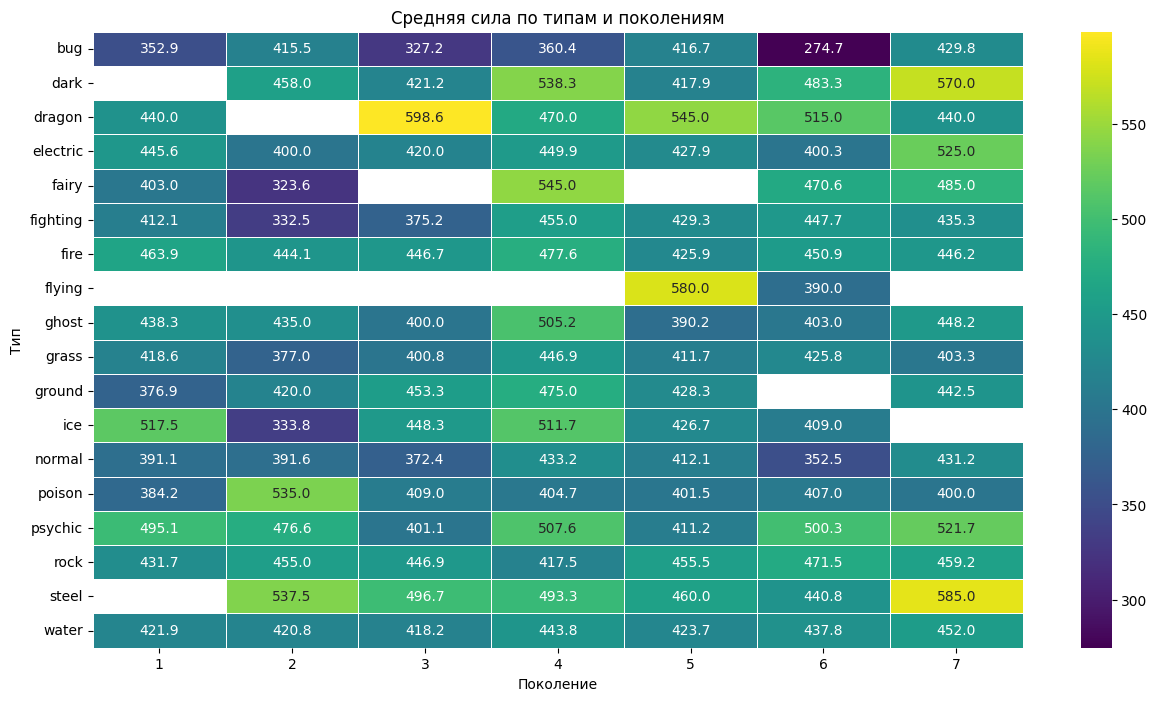

In [35]:
avg_characteristics_by_type_gen = df.groupby(['type1', 'generation'])[['hp', 'attack', 'defense', 'speed', 'base_total']].mean()
display(avg_characteristics_by_type_gen)

plt.figure(figsize=(15, 8))
sns.heatmap(avg_characteristics_by_type_gen.unstack(level='generation')['base_total'], cmap='viridis', annot=True, fmt=".1f", linewidths=.5)
plt.title('Средняя сила по типам и поколениям')
plt.xlabel('Поколение')
plt.ylabel('Тип')
plt.show()

,hp,attack,defense,speed,base_total
height_m,0.478369,0.423160,0.361938,0.202202,0.535063
weight_kg,0.427743,0.382183,0.424067,0.051384,0.458111


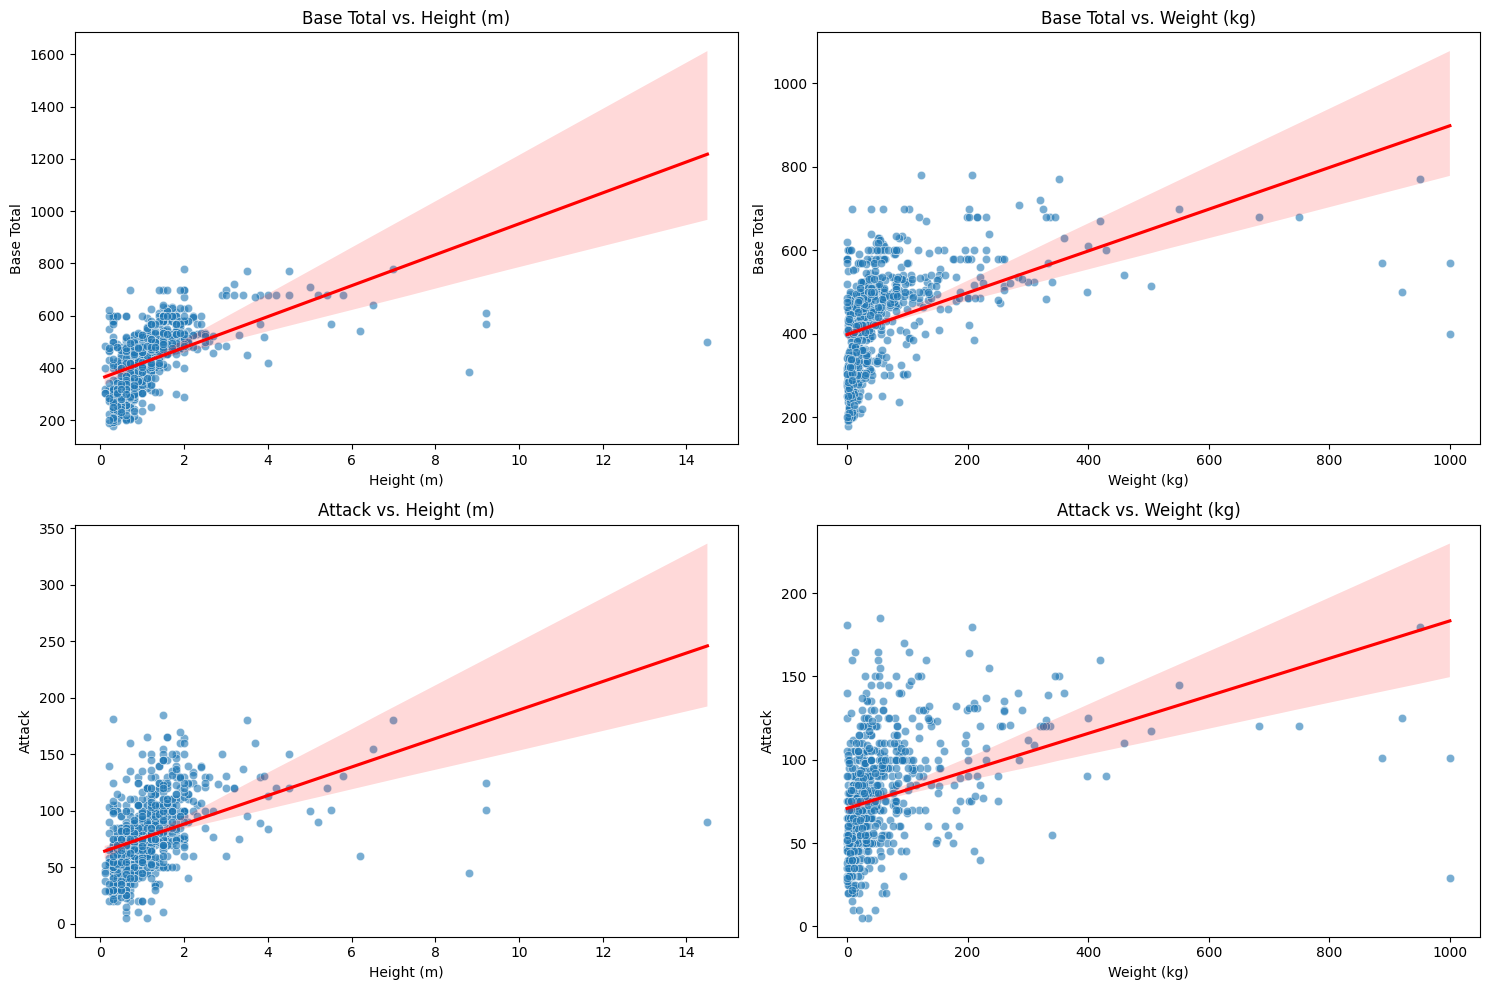

In [37]:
characteristics_cols = ['hp', 'attack', 'defense', 'speed', 'base_total']
physical_cols = ['height_m', 'weight_kg']

correlation_matrix = df[characteristics_cols + physical_cols].corr()
display(correlation_matrix.loc[physical_cols, characteristics_cols])

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='height_m', y='base_total', alpha=0.6)
sns.regplot(data=df, x='height_m', y='base_total', scatter=False, color='red')
plt.title('Base Total vs. Height (m)')
plt.xlabel('Height (m)')
plt.ylabel('Base Total')

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='weight_kg', y='base_total', alpha=0.6)
sns.regplot(data=df, x='weight_kg', y='base_total', scatter=False, color='red')
plt.title('Base Total vs. Weight (kg)')
plt.xlabel('Weight (kg)')
plt.ylabel('Base Total')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='height_m', y='attack', alpha=0.6)
sns.regplot(data=df, x='height_m', y='attack', scatter=False, color='red')
plt.title('Attack vs. Height (m)')
plt.xlabel('Height (m)')
plt.ylabel('Attack')

plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='weight_kg', y='attack', alpha=0.6)
sns.regplot(data=df, x='weight_kg', y='attack', scatter=False, color='red')
plt.title('Attack vs. Weight (kg)')
plt.xlabel('Weight (kg)')
plt.ylabel('Attack')

plt.tight_layout()
plt.show()
# можно заметить, что чем выше и тяжелее покемон, тем он сильнее
# (хотя эта зависимость не так сильно выражена, и сила может зависеть и от других характеристик)

In [41]:
# корреляция характеристик с общей силой
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
features_to_correlate = [col for col in numerical_cols if col not in ['pokedex_number', 'base_total']]
strength_correlations = df[features_to_correlate].corrwith(df['base_total']).sort_values(ascending=False)

display(strength_correlations)

# как видно из корреляционной матрицы, 'attack', 'defense', 'hp' и 'speed' очень сильно коррелируют с 'base_total', что логично, поскольку 'base_total' является суммой этих характеристик.
# факторы, которые не являются прямыми боевыми характеристиками, но показывают заметную корреляцию, включают легендарность, вес и рост. Это подтверждает, что легендарные покемоны, а также более крупные и тяжелые покемоны, как правило, имеют более высокую общую силу.
# 'capture_rate', 'base_egg_steps', 'base_happiness', 'percentage_male' имеют очень низкую или отрицательную корреляцию с 'base_total', что указывает на их слабую связь с общей силой покемона.

,0
attack,0.730134
defense,0.629620
hp,0.620624
speed,0.547666
height_m,0.535063
base_egg_steps,0.496466
is_legendary,0.485440
weight_kg,0.458111
experience_growth,0.256930
percentage_male,0.098462


## Выводы

Ключевые и наиболее интересные выводы по всему датасету и проведенному исследованию.

1. Датасет содержит подробную информацию о 801 покемоне, включая их боевые характеристики (HP, Атака, Защита и т.д.), физические параметры (рост, вес), типы, поколение и статус легендарности. Было обнаружено, что около половины покемонов не имеют второго типа.

2. В каждом поколении были определены покемоны с наивысшим общим базовым показателем (base_total). Как правило, это были легендарные покемоны или покемоны с очень высоким потенциалом развития.

3. Легендарные покемоны в среднем значительно сильнее обычных покемонов во всех поколениях. Наибольшее количество легендарных покемонов встречается среди типов Psychic (основной тип) и Flying (второй тип).

4. Выявлена умеренная положительная корреляция между физическими характеристиками (рост и вес) и общей силой покемонов (base_total), а также их атакой. Более высокие и тяжелые покемоны, как правило, демонстрируют более высокие боевые показатели, хотя это не является единственным определяющим фактором.

5. Основными предикторами общей силы покемона (base_total) являются его базовые боевые характеристики: HP, Атака, Защита, Спец. Атака, Спец. Защита и Скорость, что логично, поскольку base_total является их суммой. Помимо них, значимую положительную корреляцию с общей силой также показывают статус 'is_legendary', 'weight_kg' и 'height_m', подтверждая, что легендарность и физические размеры являются важными факторами силы.